In [6]:
# =============================================================================
# CELL 1 — Monte Carlo GP Assignment Probability: Pilot on Ganganagar District
# =============================================================================

# Purpose:
#   Pilot implementation of Monte Carlo GP assignment probability estimation
#   for NFHS clusters in Ganganagar district, Rajasthan. We start with a small geographic patch to verify the approach
#   by hand before scaling up to all of RJ and UP.
#
# Approach:
#   For each NFHS cluster in Ganganagar:
#   1. Simulate N random displacements using the actual DHS displacement
#      distribution: angle ~ Uniform[0, 2π), distance ~ Uniform[0, R]
#      where R = 5km for rural clusters, 2km for urban
#   2. For each simulated true location, identify which GP it falls in
#   3. Compute the fraction of simulations landing in each GP — this is
#      the estimated probability that the cluster's true location is in
#      that GP
#
#   This is more principled than simple area-overlap weighting because it
#   correctly implements the actual DHS displacement distribution, where
#   closer distances are more likely than the outer edge of the buffer
#   (uniform on distance, not on area).
#
# Note on ALT_DEM:
#   ALT_DEM is recorded at the displaced GPS location
#   (a simple SRTM lookup), not the true cluster location. Ganganagar is
#   flat plains so elevation filtering is not applied in this pilot.
#
# Data requirements:
#   Same as cluster_GPs_cleaning.ipynb — all files in ../data/
#
# Pilot district: Ganganagar, Rajasthan (pc11_d_id = "099")
#   3,034 SHRUG village polygons
#   Rajasthan chosen for pilot due to near-complete LGD coverage (87.6%)

In [3]:
# =============================================================================
# CELL 2 — Imports and Paths
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print(f"geopandas: {gpd.__version__}")
print(f"pandas:    {pd.__version__}")
print(f"numpy:     {np.__version__}")

# ── Relative paths ────────────────────────────────────────────────────────────
DATA_DIR = Path("../data")

RJ_VILLAGES_PATH  = DATA_DIR / "shrug rajasthan village polygons" / "shrug_rajasthan_villages.shp"
NFHS4_GPS_PATH    = DATA_DIR / "nfhs4" / "nfhs4_gps_clusters.shp"
NFHS5_GPS_PATH    = DATA_DIR / "nfhs5" / "nfhs5_gps_clusters.shp"
SHRUG_LGD_PATH    = DATA_DIR / "shrug_LGD_matched.csv"

# ── Constants ─────────────────────────────────────────────────────────────────
PROJECTED_CRS       = "EPSG:32644"   # UTM Zone 44N (metres)
PILOT_DISTRICT      = "099"          # Ganganagar, Rajasthan
PILOT_STATE         = "08"           # Rajasthan
N_SIMULATIONS       = 1000           # Monte Carlo draws per cluster
RURAL_DISPLACEMENT  = 5000           # metres
URBAN_DISPLACEMENT  = 2000           # metres
RANDOM_SEED         = 42             # for reproducibility

# ── Verify files ──────────────────────────────────────────────────────────────
print("\nChecking required files:")
for path in [RJ_VILLAGES_PATH, NFHS4_GPS_PATH, NFHS5_GPS_PATH, SHRUG_LGD_PATH]:
    status = "✓" if path.exists() else "✗ NOT FOUND"
    print(f"  {status}  {path}")

geopandas: 1.1.3
pandas:    3.0.2
numpy:     1.26.4

Checking required files:
  ✓  ../data/shrug rajasthan village polygons/shrug_rajasthan_villages.shp
  ✓  ../data/nfhs4/nfhs4_gps_clusters.shp
  ✓  ../data/nfhs5/nfhs5_gps_clusters.shp
  ✓  ../data/shrug_LGD_matched.csv


In [4]:
# =============================================================================
# CELL 3 — Load and Prepare Ganganagar Village Polygons
# =============================================================================

print("Loading Rajasthan village polygons...")
rj_villages = gpd.read_file(RJ_VILLAGES_PATH)
print(f"Total Rajasthan villages: {len(rj_villages)}")

# Filter to Ganganagar district
ganganagar_villages = rj_villages[
    rj_villages["pc11_d_id"] == PILOT_DISTRICT
].copy()
print(f"Ganganagar villages: {len(ganganagar_villages)}")

# Reproject to metres
ganganagar_villages = ganganagar_villages.to_crs(PROJECTED_CRS)
print(f"CRS: {ganganagar_villages.crs}")
print(f"Columns: {ganganagar_villages.columns.tolist()}")

Loading Rajasthan village polygons...
Total Rajasthan villages: 44976
Ganganagar villages: 3034
CRS: EPSG:32644
Columns: ['pc11_s_id', 'pc11_d_id', 'pc11_sd_id', 'pc11_tv_id', 'tv_name', 'geometry']


In [5]:
# =============================================================================
# CELL 4 — Assign GP Codes to Ganganagar Villages
# =============================================================================

print("Loading SHRUG-LGD crosswalk...")
shrug_lgd = pd.read_csv(SHRUG_LGD_PATH, encoding="latin-1", low_memory=False)

# Build GP code column
def get_gp_code(row):
    if row["gp_to_urban_conversion"] == "Yes" and pd.notna(row["old_gp_lgd_code"]):
        return row["old_gp_lgd_code"]
    elif pd.notna(row["LGD_code"]) and row["local_body_type"] == "Gram Panchayat":
        return row["LGD_code"]
    return None

def get_gp_name(row):
    if row["gp_to_urban_conversion"] == "Yes" and pd.notna(row["old_gp_name"]):
        return row["old_gp_name"]
    elif pd.notna(row["local_body_name"]) and row["local_body_type"] == "Gram Panchayat":
        return row["local_body_name"]
    return None

shrug_lgd["gp_lgd_code"] = shrug_lgd.apply(get_gp_code, axis=1)
shrug_lgd["gp_name"]     = shrug_lgd.apply(get_gp_name, axis=1)

lgd_gp = shrug_lgd[shrug_lgd["gp_lgd_code"].notna()][
    ["shrid2", "gp_lgd_code", "gp_name"]
].copy().rename(columns={"shrid2": "shrid2_key"})

# Build shrid2 key and merge
ganganagar_villages["shrid2_key"] = (
    "11-" +
    ganganagar_villages["pc11_s_id"].astype(str).str.zfill(2)  + "-" +
    ganganagar_villages["pc11_d_id"].astype(str).str.zfill(3)  + "-" +
    ganganagar_villages["pc11_sd_id"].astype(str).str.zfill(5) + "-" +
    ganganagar_villages["pc11_tv_id"].astype(str).str.zfill(6)
)

ganganagar_villages = ganganagar_villages.merge(lgd_gp, on="shrid2_key", how="left")

matched = ganganagar_villages["gp_lgd_code"].notna().mean()
print(f"Villages with GP code: {ganganagar_villages['gp_lgd_code'].notna().sum()} ({matched:.1%})")
print(f"Unique GPs in Ganganagar: {ganganagar_villages['gp_lgd_code'].nunique()}")

Loading SHRUG-LGD crosswalk...
Villages with GP code: 2840 (93.6%)
Unique GPs in Ganganagar: 343


In [7]:
# =============================================================================
# CELL 5 — Dissolve Village Polygons to GP Level
# =============================================================================
# This is the key new step: merging village polygons up to GP boundaries
# by grouping all villages that share the same gp_lgd_code.
# Required for the Monte Carlo — we need to know which GP each
# simulated point falls in.

print("Dissolving village polygons to GP level...")

gp_polygons = (
    ganganagar_villages[ganganagar_villages["gp_lgd_code"].notna()]
    .dissolve(by="gp_lgd_code", as_index=False)
    [["gp_lgd_code", "gp_name", "geometry"]]
)

print(f"GP polygons created: {len(gp_polygons)}")
print(f"Sample GP names:")
print(gp_polygons["gp_name"].head(10).tolist())

# Basic geometry check
invalid = (~gp_polygons.geometry.is_valid).sum()
print(f"\nInvalid geometries: {invalid}")
if invalid > 0:
    print("Fixing invalid geometries with buffer(0)...")
    gp_polygons["geometry"] = gp_polygons.geometry.buffer(0)
    print(f"Invalid after fix: {(~gp_polygons.geometry.is_valid).sum()}")

Dissolving village polygons to GP level...
GP polygons created: 343
Sample GP names:
['2 Kwm', '1 Lsm', '1 Mlk C', '1 Skm B', '10 As', '10 Dol', '10 Kd', '10 Sarkari', '11:00 PM', '11 12 Nd (Nahranwali)']

Invalid geometries: 0


In [16]:
# =============================================================================
# CELL 6 — Load and Filter NFHS Clusters to Ganganagar
# =============================================================================

def load_clusters_for_district(path, round_name, state_code, district_name):
    """
    Load GPS clusters, filter to pilot district using spatial join
    with the GP polygons bounding box.
    """
    print(f"\nLoading {round_name} clusters...")
    gdf = gpd.read_file(path)

    gdf = gdf[["DHSCLUST", "LATNUM", "LONGNUM",
                "URBAN_RURA", "ADM1NAME", "DHSREGNA"]].copy()
    gdf["ADM1NAME"] = gdf["ADM1NAME"].str.strip().str.upper()

    # Drop zero-coordinate clusters
    gdf = gdf[(gdf["LATNUM"] != 0) & (gdf["LONGNUM"] != 0)].copy()

    # Filter to Rajasthan
    gdf = gdf[gdf["ADM1NAME"] == "RAJASTHAN"].copy()

    # Convert to GeoDataFrame and reproject
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf.LONGNUM, gdf.LATNUM),
        crs="EPSG:4326"
    ).to_crs(PROJECTED_CRS)

    # Filter to Ganganagar using spatial join with GP polygons
    # Filter to Ganganagar by district name from DHS file
    gdf = gdf[gdf["DHSREGNA"].str.upper().str.contains("GANGANAGAR")].copy()
    gdf["round"] = round_name

    print(f"  {round_name} clusters in Ganganagar: {len(gdf)}")
    print(gdf["URBAN_RURA"].value_counts().to_string())
    return gdf

nfhs4_ganganagar = load_clusters_for_district(
    NFHS4_GPS_PATH, "NFHS4", PILOT_STATE, PILOT_DISTRICT
)
nfhs5_ganganagar = load_clusters_for_district(
    NFHS5_GPS_PATH, "NFHS5", PILOT_STATE, PILOT_DISTRICT
)


Loading NFHS4 clusters...
  NFHS4 clusters in Ganganagar: 43
URBAN_RURA
R    31
U    12

Loading NFHS5 clusters...
  NFHS5 clusters in Ganganagar: 45
URBAN_RURA
R    33
U    12


In [17]:
# =============================================================================
# CELL 7 — Monte Carlo GP Assignment Probability
# =============================================================================
# For each cluster, simulate N random displacements using the actual DHS
# displacement distribution:
#   angle    ~ Uniform[0, 2π)
#   distance ~ Uniform[0, R]  where R = 5km rural, 2km urban
#
# For each simulated true location, identify which GP it falls in.
# The fraction of simulations in each GP = P(true GP = k | observed D).

def run_monte_carlo(clusters, gp_polygons, n_simulations, random_seed):
    """
    Run Monte Carlo GP assignment for a set of clusters.
    Returns DataFrame with GP probability distributions per cluster.
    """
    np.random.seed(random_seed)
    results = []

    print(f"Running Monte Carlo ({n_simulations} simulations per cluster)...")
    print(f"Clusters to process: {len(clusters)}")

    for i, (_, cluster) in enumerate(clusters.iterrows()):
        if i % 10 == 0:
            print(f"  Processing cluster {i+1}/{len(clusters)}...")

        # Displacement radius based on urban/rural
        R = RURAL_DISPLACEMENT if cluster["URBAN_RURA"] == "R" \
            else URBAN_DISPLACEMENT

        # Draw random angles and distances
        # Per DHS README:
        # angle    ~ Uniform[0, 2π)
        # distance ~ Uniform[0, R]
        angles    = np.random.uniform(0, 2 * np.pi, n_simulations)
        distances = np.random.uniform(0, R, n_simulations)

        # Convert to x, y offsets
        x_offsets = distances * np.cos(angles)
        y_offsets = distances * np.sin(angles)

        # Simulated true locations
        cx = cluster.geometry.x
        cy = cluster.geometry.y
        sim_x = cx + x_offsets
        sim_y = cy + y_offsets

        # Create GeoDataFrame of simulated points
        sim_points = gpd.GeoDataFrame(
            {"sim_id": range(n_simulations)},
            geometry=gpd.points_from_xy(sim_x, sim_y),
            crs=PROJECTED_CRS
        )

        # Spatial join: which GP does each simulated point fall in?
        joined = gpd.sjoin(
            sim_points,
            gp_polygons[["gp_lgd_code", "gp_name", "geometry"]],
            how="left",
            predicate="within"
        )

        # Count simulations per GP
        gp_counts = joined["gp_lgd_code"].value_counts()
        n_outside  = joined["gp_lgd_code"].isna().sum()
        n_assigned = n_simulations - n_outside

        # Primary GP (most simulations)
        primary_gp      = gp_counts.index[0] if len(gp_counts) > 0 else None
        primary_gp_prob = gp_counts.iloc[0] / n_simulations if len(gp_counts) > 0 else 0
        n_gps_hit       = len(gp_counts)

        results.append({
            "DHSCLUST":          cluster["DHSCLUST"],
            "URBAN_RURA":        cluster["URBAN_RURA"],
            "DHSREGNA":          cluster["DHSREGNA"],
            "round":             cluster["round"],
            "displacement_R_m":  R,
            "primary_gp":        primary_gp,
            "primary_gp_prob":   round(primary_gp_prob, 4),
            "n_gps_hit":         n_gps_hit,
            "n_outside_any_gp":  n_outside,
            "gp_distribution":   dict(gp_counts),
        })

    return pd.DataFrame(results)

# Run for both rounds
mc_nfhs4 = run_monte_carlo(nfhs4_ganganagar, gp_polygons, N_SIMULATIONS, RANDOM_SEED)
mc_nfhs5 = run_monte_carlo(nfhs5_ganganagar, gp_polygons, N_SIMULATIONS, RANDOM_SEED)

print("\nDone.")

Running Monte Carlo (1000 simulations per cluster)...
Clusters to process: 43
  Processing cluster 1/43...
  Processing cluster 11/43...
  Processing cluster 21/43...
  Processing cluster 31/43...
  Processing cluster 41/43...
Running Monte Carlo (1000 simulations per cluster)...
Clusters to process: 45
  Processing cluster 1/45...
  Processing cluster 11/45...
  Processing cluster 21/45...
  Processing cluster 31/45...
  Processing cluster 41/45...

Done.


In [18]:
# =============================================================================
# CELL 8 — Summary Statistics
# =============================================================================

def summarise_mc(mc_df, round_name):
    rural = mc_df[mc_df["URBAN_RURA"] == "R"]
    print(f"\n── {round_name} rural clusters in Ganganagar ──")
    print(f"Total clusters:                    {len(rural)}")
    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")
    print(f"Clusters with P > 0.8 (low risk):  {(rural['primary_gp_prob'] > 0.8).sum()} ({(rural['primary_gp_prob'] > 0.8).mean():.1%})")
    print(f"Clusters with P > 0.5:             {(rural['primary_gp_prob'] > 0.5).sum()} ({(rural['primary_gp_prob'] > 0.5).mean():.1%})")
    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Simulations outside any GP:        {rural['n_outside_any_gp'].mean():.1f} avg per cluster")
    print(f"\nP(primary GP) distribution:")
    bins = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())

summarise_mc(mc_nfhs4, "NFHS4")
summarise_mc(mc_nfhs5, "NFHS5")


── NFHS4 rural clusters in Ganganagar ──
Total clusters:                    31
Mean P(primary GP):                0.379
Median P(primary GP):              0.363
Clusters with P > 0.8 (low risk):  0 (0.0%)
Clusters with P > 0.5:             3 (9.7%)
Mean GPs hit per cluster:          7.90
Simulations outside any GP:        126.5 avg per cluster

P(primary GP) distribution:
prob_bin
0-25%      1
25-50%    27
50-75%     3
75-90%     0
>90%       0

── NFHS5 rural clusters in Ganganagar ──
Total clusters:                    33
Mean P(primary GP):                0.370
Median P(primary GP):              0.358
Clusters with P > 0.8 (low risk):  0 (0.0%)
Clusters with P > 0.5:             2 (6.1%)
Mean GPs hit per cluster:          8.06
Simulations outside any GP:        126.5 avg per cluster

P(primary GP) distribution:
prob_bin
0-25%      1
25-50%    29
50-75%     2
75-90%     0
>90%       0


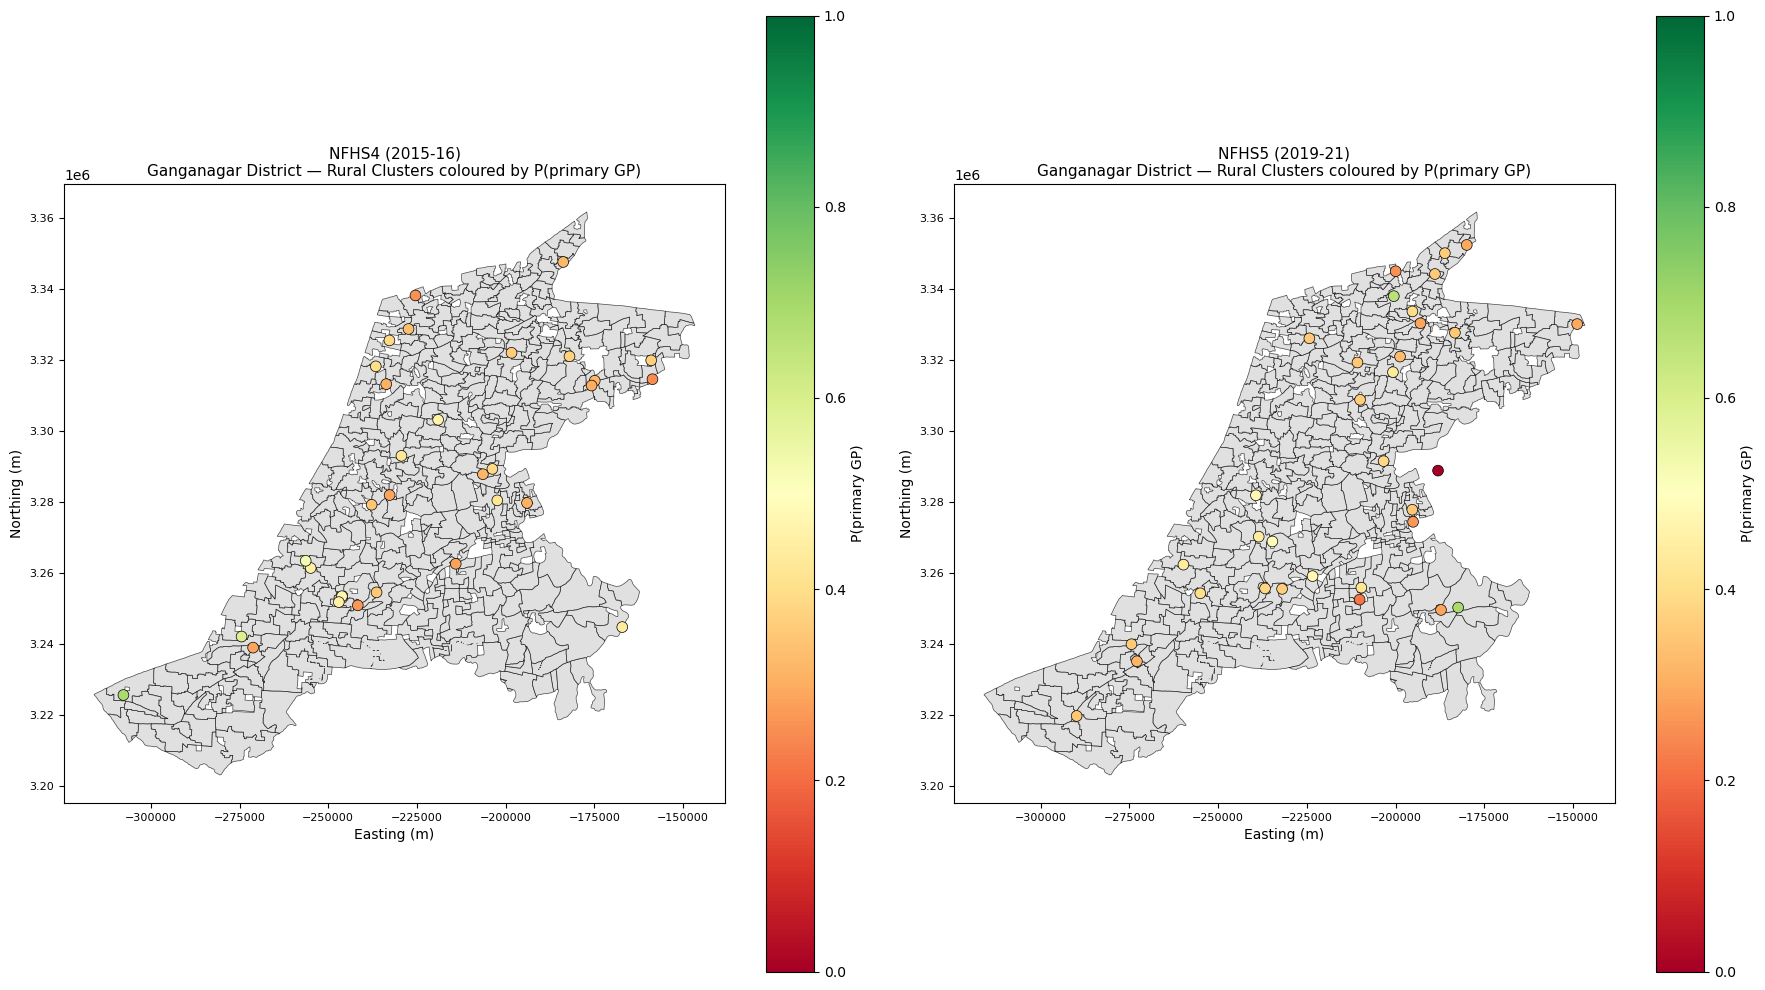

Map saved.


In [31]:
# =============================================================================
# CELL 9 — Visualisation
# =============================================================================
# Plot GP boundaries, cluster locations, and colour clusters by
# P(primary GP) so we can visually verify the Monte Carlo results.
from pathlib import Path

# Save to Monte Carlo subfolder within outputs/
OUTPUT_DIR = Path("../outputs/monte carlo simulation ganganagar")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)   # creates folder if it doesn't already exist

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, mc_df, round_name in [
    (axes[0], mc_nfhs4, "NFHS4 (2015-16)"),
    (axes[1], mc_nfhs5, "NFHS5 (2019-21)")
]:
    # Plot GP boundaries
    gp_polygons.plot(
        ax=ax,
        color="lightgrey",
        edgecolor="black",
        linewidth=0.5,
        alpha=0.7
    )

    # Merge MC results with cluster locations for plotting
    rural_mc = mc_df[mc_df["URBAN_RURA"] == "R"].copy()
    clusters_plot = (
        nfhs4_ganganagar if round_name.startswith("NFHS4")
        else nfhs5_ganganagar
    )
    clusters_plot = clusters_plot[clusters_plot["URBAN_RURA"] == "R"].merge(
        rural_mc[["DHSCLUST", "primary_gp_prob", "n_gps_hit"]],
        on="DHSCLUST", how="left"
    )

    # Colour by P(primary GP)
    scatter = ax.scatter(
        clusters_plot.geometry.x,
        clusters_plot.geometry.y,
        c=clusters_plot["primary_gp_prob"],
        cmap="RdYlGn",
        vmin=0, vmax=1,
        s=60,
        edgecolors="black",
        linewidth=0.5,
        zorder=5
    )

    plt.colorbar(scatter, ax=ax, label="P(primary GP)")
    ax.set_title(f"{round_name}\nGanganagar District — Rural Clusters coloured by P(primary GP)",
                 fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ganganagar_monte_carlo_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Map saved.")

Generating zoomed-in maps for hand-checking...
  High confidence cluster (P = 68.9%)


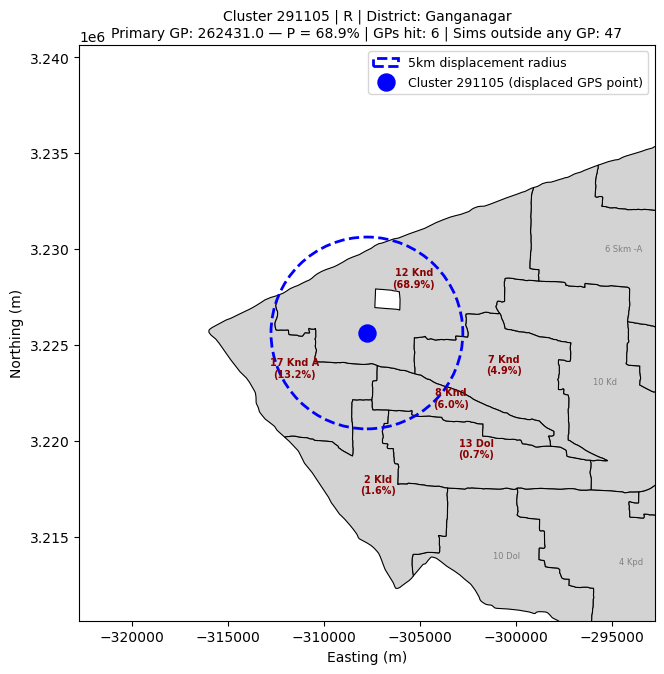

  Medium confidence cluster (P = 36.3%)


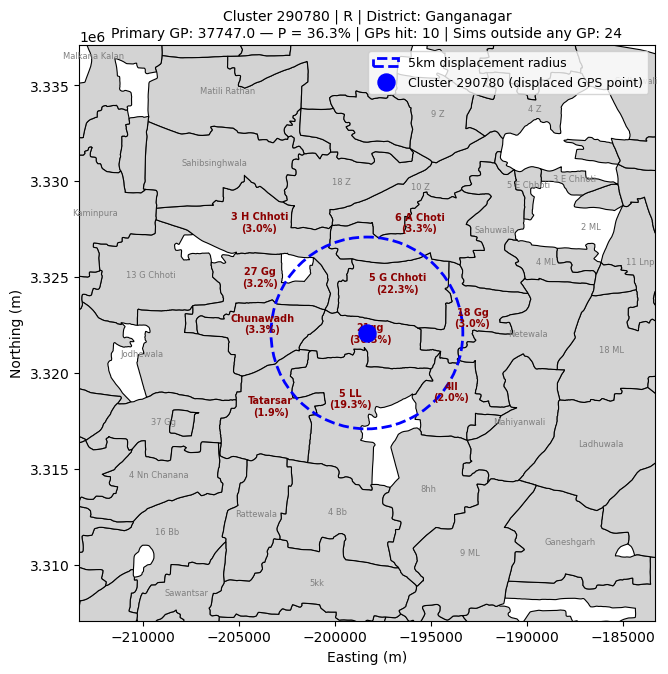

  Low confidence / border cluster (P = 24.9%)


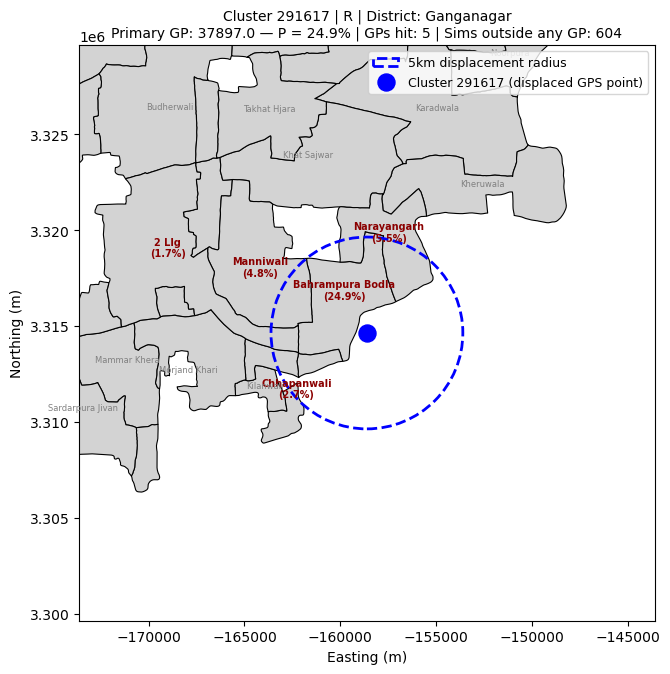

In [23]:
# =============================================================================
# CELL 10 — Zoomed-In Cluster Detail Maps for Hand-Checking
# =============================================================================
# verify the Monte Carlo results by hand
# before scaling up. This cell produces one zoomed-in map per cluster
# showing:
#   - GP boundaries with names and Monte Carlo probabilities labelled
#   - The cluster GPS point (displaced location)
#   - The 5km displacement radius circle
#
# This allows visual verification that the probability distribution makes
# geographic sense — e.g. a cluster near the boundary between two GPs
# should show a split probability, while a cluster in the centre of a
# large GP should show a dominant probability for that GP.

def plot_cluster_detail(dhsclust, mc_df, clusters_gdf, gp_polygons):
    """Zoomed-in map for hand-checking one cluster's Monte Carlo results."""

    mc_row  = mc_df[mc_df["DHSCLUST"] == dhsclust].iloc[0]
    cluster = clusters_gdf[clusters_gdf["DHSCLUST"] == dhsclust].iloc[0]

    cx, cy = cluster.geometry.x, cluster.geometry.y
    R      = RURAL_DISPLACEMENT if cluster["URBAN_RURA"] == "R" \
             else URBAN_DISPLACEMENT

    # Zoom window: 3x the displacement radius around the cluster
    margin = R * 3
    bbox   = (cx - margin, cy - margin, cx + margin, cy + margin)

    # Filter GP polygons to zoom window only
    gps_nearby = gp_polygons.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    # Plot GP boundaries
    gps_nearby.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.8)

    # Label each GP with name and Monte Carlo probability
    gp_dist = mc_row["gp_distribution"]
    for _, gp in gps_nearby.iterrows():
        prob     = gp_dist.get(gp["gp_lgd_code"], 0) / N_SIMULATIONS
        centroid = gp.geometry.centroid
        if prob > 0:
            ax.annotate(
                f"{gp['gp_name']}\n({prob:.1%})",
                xy=(centroid.x, centroid.y),
                fontsize=7, ha="center",
                color="darkred", fontweight="bold"
            )
        else:
            ax.annotate(
                gp["gp_name"],
                xy=(centroid.x, centroid.y),
                fontsize=6, ha="center", color="grey"
            )

    # Plot displacement radius circle
    circle = plt.Circle(
        (cx, cy), R,
        color="blue", fill=False,
        linewidth=2, linestyle="--",
        label=f"{R/1000:.0f}km displacement radius"
    )
    ax.add_patch(circle)

    # Plot cluster GPS point
    ax.scatter(
        cx, cy,
        color="blue", s=150, zorder=5,
        label=f"Cluster {int(dhsclust)} (displaced GPS point)"
    )

    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])
    ax.set_title(
        f"Cluster {int(dhsclust)} | {mc_row['URBAN_RURA']} | "
        f"District: {mc_row['DHSREGNA']}\n"
        f"Primary GP: {mc_row['primary_gp']} — P = {mc_row['primary_gp_prob']:.1%} | "
        f"GPs hit: {mc_row['n_gps_hit']} | "
        f"Sims outside any GP: {mc_row['n_outside_any_gp']}",
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()

# ── Plot the three hand-check clusters ───────────────────────────────────────
# These span the probability range: high confidence, medium, and low/border
print("Generating zoomed-in maps for hand-checking...")
print("  High confidence cluster (P = 68.9%)")
plot_cluster_detail(291105.0, mc_nfhs4, nfhs4_ganganagar, gp_polygons)

print("  Medium confidence cluster (P = 36.3%)")
plot_cluster_detail(290780.0, mc_nfhs4, nfhs4_ganganagar, gp_polygons)

print("  Low confidence / border cluster (P = 24.9%)")
plot_cluster_detail(291617.0, mc_nfhs4, nfhs4_ganganagar, gp_polygons)

In [24]:
# =============================================================================
# CELL 11 — Hand-Check Sample Clusters
# =============================================================================
# Inspect a few clusters manually to verify
# the Monte Carlo probabilities make intuitive sense.
# We pick clusters spanning the probability range for spot-checking.

def hand_check_cluster(dhsclust, mc_df, clusters_gdf, gp_polygons, n_display=5):
    """Print detailed Monte Carlo results for one cluster."""
    mc_row   = mc_df[mc_df["DHSCLUST"] == dhsclust].iloc[0]
    clust    = clusters_gdf[clusters_gdf["DHSCLUST"] == dhsclust].iloc[0]

    print(f"\n── Cluster {dhsclust} ──────────────────────────────────────")
    print(f"  Location:       ({clust.geometry.x:.0f}, {clust.geometry.y:.0f}) UTM")
    print(f"  Urban/Rural:    {mc_row['URBAN_RURA']}")
    print(f"  District:       {mc_row['DHSREGNA']}")
    print(f"  Displacement R: {mc_row['displacement_R_m']}m")
    print(f"  Primary GP:     {mc_row['primary_gp']} (P = {mc_row['primary_gp_prob']:.1%})")
    print(f"  GPs hit:        {mc_row['n_gps_hit']}")
    print(f"  Sims outside:   {mc_row['n_outside_any_gp']}")
    print(f"\n  GP probability distribution (top {n_display}):")

    gp_dist = mc_row["gp_distribution"]
    for gp_code, count in sorted(gp_dist.items(), key=lambda x: -x[1])[:n_display]:
        gp_name = gp_polygons[gp_polygons["gp_lgd_code"] == gp_code]["gp_name"].values
        name = gp_name[0] if len(gp_name) > 0 else "Unknown"
        prob = count / N_SIMULATIONS
        bar  = "█" * int(prob * 40)
        print(f"    {name:<25} {prob:.1%}  {bar}")

# Pick clusters spanning the probability range
rural_mc4 = mc_nfhs4[mc_nfhs4["URBAN_RURA"] == "R"].sort_values("primary_gp_prob")

high_conf  = rural_mc4.iloc[-1]["DHSCLUST"]   # highest P(primary GP)
mid_conf   = rural_mc4.iloc[len(rural_mc4)//2]["DHSCLUST"]  # median
low_conf   = rural_mc4.iloc[0]["DHSCLUST"]    # lowest P(primary GP)

print("Sample clusters for hand-checking (NFHS4):")
for dhsclust in [high_conf, mid_conf, low_conf]:
    hand_check_cluster(dhsclust, mc_nfhs4, nfhs4_ganganagar, gp_polygons)

Sample clusters for hand-checking (NFHS4):

── Cluster 291105.0 ──────────────────────────────────────
  Location:       (-307752, 3225624) UTM
  Urban/Rural:    R
  District:       Ganganagar
  Displacement R: 5000m
  Primary GP:     262431.0 (P = 68.9%)
  GPs hit:        6
  Sims outside:   47

  GP probability distribution (top 5):
    12 Knd                    68.9%  ███████████████████████████
    17 Knd A                  13.2%  █████
    8 Knd                     6.0%  ██
    7 Knd                     4.9%  █
    2 Kld                     1.6%  

── Cluster 290780.0 ──────────────────────────────────────
  Location:       (-198346, 3322087) UTM
  Urban/Rural:    R
  District:       Ganganagar
  Displacement R: 5000m
  Primary GP:     37747.0 (P = 36.3%)
  GPs hit:        10
  Sims outside:   24

  GP probability distribution (top 5):
    21gg                      36.3%  ██████████████
    5 G Chhoti                22.3%  ████████
    5 LL                      19.3%  ███████
    

In [32]:
# =============================================================================
# CELL 12 — Save Results
# =============================================================================

from pathlib import Path

# Save to Monte Carlo subfolder within outputs/
OUTPUT_DIR = Path("../outputs/monte carlo simulation ganganagar")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)   # creates folder if it doesn't already exist

mc_nfhs4.to_csv(OUTPUT_DIR / "ganganagar_mc_nfhs4.csv", index=False)
mc_nfhs5.to_csv(OUTPUT_DIR / "ganganagar_mc_nfhs5.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_DIR / 'ganganagar_mc_nfhs4.csv'}")
print(f"  {OUTPUT_DIR / 'ganganagar_mc_nfhs5.csv'}")
print(f"\nRows: NFHS4={len(mc_nfhs4)}, NFHS5={len(mc_nfhs5)}")

Saved:
  ../outputs/monte carlo simulation ganganagar/ganganagar_mc_nfhs4.csv
  ../outputs/monte carlo simulation ganganagar/ganganagar_mc_nfhs5.csv

Rows: NFHS4=43, NFHS5=45


In [33]:
# =============================================================================
# CELL 12 — Load All Rajasthan Village Polygons and Assign GP Codes
# =============================================================================
# Extends the Ganganagar pilot to all of Rajasthan.
# Same GP code assignment approach as Cell 3-4 but no district filter.

print("Loading all Rajasthan village polygons...")
rj_villages_all = gpd.read_file(RJ_VILLAGES_PATH)
print(f"Total Rajasthan villages: {len(rj_villages_all)}")

# Reproject to metres
rj_villages_all = rj_villages_all.to_crs(PROJECTED_CRS)

# Assign GP codes using same shrid2 key approach
rj_villages_all["shrid2_key"] = (
    "11-" +
    rj_villages_all["pc11_s_id"].astype(str).str.zfill(2)  + "-" +
    rj_villages_all["pc11_d_id"].astype(str).str.zfill(3)  + "-" +
    rj_villages_all["pc11_sd_id"].astype(str).str.zfill(5) + "-" +
    rj_villages_all["pc11_tv_id"].astype(str).str.zfill(6)
)

rj_villages_all = rj_villages_all.merge(lgd_gp, on="shrid2_key", how="left")

matched = rj_villages_all["gp_lgd_code"].notna().mean()
print(f"Villages with GP code: {rj_villages_all['gp_lgd_code'].notna().sum()} ({matched:.1%})")
print(f"Unique GPs in Rajasthan: {rj_villages_all['gp_lgd_code'].nunique()}")

Loading all Rajasthan village polygons...
Total Rajasthan villages: 44976
Villages with GP code: 39420 (87.6%)
Unique GPs in Rajasthan: 11107


In [34]:
# =============================================================================
# CELL 13 — Dissolve All Rajasthan Villages to GP Polygons
# =============================================================================
# Merges village polygons into GP-level boundaries for all of Rajasthan.
# This is the key input for the Monte Carlo — we need GP boundaries to
# check which GP each simulated displacement point falls in.
# Saved to outputs/ so it doesn't need to be recomputed each run.

print("Dissolving village polygons to GP level (all Rajasthan)...")
print("This may take a few minutes...")

gp_polygons_rj = (
    rj_villages_all[rj_villages_all["gp_lgd_code"].notna()]
    .dissolve(by="gp_lgd_code", as_index=False)
    [["gp_lgd_code", "gp_name", "geometry"]]
)

print(f"GP polygons created: {len(gp_polygons_rj)}")

# Fix any invalid geometries
invalid = (~gp_polygons_rj.geometry.is_valid).sum()
print(f"Invalid geometries: {invalid}")
if invalid > 0:
    print("Fixing invalid geometries...")
    gp_polygons_rj["geometry"] = gp_polygons_rj.geometry.buffer(0)
    print(f"Invalid after fix: {(~gp_polygons_rj.geometry.is_valid).sum()}")

# Save GP polygons for reuse
GP_POLYGONS_PATH = OUTPUT_DIR / "rajasthan_gp_polygons.gpkg"
gp_polygons_rj.to_file(GP_POLYGONS_PATH, driver="GPKG")
print(f"\nSaved GP polygons to: {GP_POLYGONS_PATH}")

Dissolving village polygons to GP level (all Rajasthan)...
This may take a few minutes...
GP polygons created: 11107
Invalid geometries: 0

Saved GP polygons to: ../outputs/monte carlo simulation ganganagar/rajasthan_gp_polygons.gpkg


In [35]:
# =============================================================================
# CELL 14 — Load All Rajasthan NFHS Clusters
# =============================================================================

def load_rajasthan_clusters(path, round_name):
    """Load rural Rajasthan NFHS clusters for Monte Carlo."""
    print(f"\nLoading {round_name} clusters...")
    gdf = gpd.read_file(path)

    gdf = gdf[["DHSCLUST", "LATNUM", "LONGNUM",
                "URBAN_RURA", "ADM1NAME", "DHSREGNA"]].copy()
    gdf["ADM1NAME"] = gdf["ADM1NAME"].str.strip().str.upper()

    # Drop zero-coordinate clusters
    gdf = gdf[(gdf["LATNUM"] != 0) & (gdf["LONGNUM"] != 0)].copy()

    # Filter to Rajasthan rural only
    # (Monte Carlo is designed for rural clusters with 5km displacement)
    gdf = gdf[
        (gdf["ADM1NAME"] == "RAJASTHAN") &
        (gdf["URBAN_RURA"] == "R")
    ].copy()

    gdf["round"] = round_name

    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf.LONGNUM, gdf.LATNUM),
        crs="EPSG:4326"
    ).to_crs(PROJECTED_CRS)

    print(f"  {round_name} rural Rajasthan clusters: {len(gdf)}")
    print(f"  Districts covered: {gdf['DHSREGNA'].nunique()}")
    return gdf

nfhs4_rj = load_rajasthan_clusters(NFHS4_GPS_PATH, "NFHS4")
nfhs5_rj = load_rajasthan_clusters(NFHS5_GPS_PATH, "NFHS5")


Loading NFHS4 clusters...
  NFHS4 rural Rajasthan clusters: 1190
  Districts covered: 33

Loading NFHS5 clusters...
  NFHS5 rural Rajasthan clusters: 1163
  Districts covered: 33


In [36]:
# =============================================================================
# CELL 15 — Run Monte Carlo for All Rajasthan Clusters
# =============================================================================
# Runs the same Monte Carlo simulation as the Ganganagar pilot but
# across all rural Rajasthan clusters in both NFHS4 and NFHS5.
# Uses the same run_monte_carlo function defined in Cell 7.

print("Running Monte Carlo for all Rajasthan rural clusters...")
print(f"NFHS4: {len(nfhs4_rj)} clusters × {N_SIMULATIONS} simulations")
print(f"NFHS5: {len(nfhs5_rj)} clusters × {N_SIMULATIONS} simulations")

mc_nfhs4_rj = run_monte_carlo(nfhs4_rj, gp_polygons_rj, N_SIMULATIONS, RANDOM_SEED)
mc_nfhs5_rj = run_monte_carlo(nfhs5_rj, gp_polygons_rj, N_SIMULATIONS, RANDOM_SEED)

print("\nDone.")

Running Monte Carlo for all Rajasthan rural clusters...
NFHS4: 1190 clusters × 1000 simulations
NFHS5: 1163 clusters × 1000 simulations
Running Monte Carlo (1000 simulations per cluster)...
Clusters to process: 1190
  Processing cluster 1/1190...
  Processing cluster 11/1190...
  Processing cluster 21/1190...
  Processing cluster 31/1190...
  Processing cluster 41/1190...
  Processing cluster 51/1190...
  Processing cluster 61/1190...
  Processing cluster 71/1190...
  Processing cluster 81/1190...
  Processing cluster 91/1190...
  Processing cluster 101/1190...
  Processing cluster 111/1190...
  Processing cluster 121/1190...
  Processing cluster 131/1190...
  Processing cluster 141/1190...
  Processing cluster 151/1190...
  Processing cluster 161/1190...
  Processing cluster 171/1190...
  Processing cluster 181/1190...
  Processing cluster 191/1190...
  Processing cluster 201/1190...
  Processing cluster 211/1190...
  Processing cluster 221/1190...
  Processing cluster 231/1190...
  P

In [37]:
# =============================================================================
# CELL 16 — Summary Statistics: Full Rajasthan
# =============================================================================

print("=" * 70)
print("MONTE CARLO RESULTS: ALL RAJASTHAN RURAL CLUSTERS")
print("=" * 70)

for name, df in [("NFHS4 (2015-16)", mc_nfhs4_rj),
                  ("NFHS5 (2019-21)", mc_nfhs5_rj)]:
    rural = df[df["URBAN_RURA"] == "R"]
    print(f"\n── {name} ──────────────────────────────────────")
    print(f"Total rural clusters:              {len(rural)}")
    print(f"Mean P(primary GP):                {rural['primary_gp_prob'].mean():.3f}")
    print(f"Median P(primary GP):              {rural['primary_gp_prob'].median():.3f}")
    print(f"Clusters with P > 0.9:             "
          f"{(rural['primary_gp_prob'] > 0.9).sum()} "
          f"({(rural['primary_gp_prob'] > 0.9).mean():.1%})")
    print(f"Clusters with P > 0.8:             "
          f"{(rural['primary_gp_prob'] > 0.8).sum()} "
          f"({(rural['primary_gp_prob'] > 0.8).mean():.1%})")
    print(f"Clusters with P > 0.5:             "
          f"{(rural['primary_gp_prob'] > 0.5).sum()} "
          f"({(rural['primary_gp_prob'] > 0.5).mean():.1%})")
    print(f"Mean GPs hit per cluster:          {rural['n_gps_hit'].mean():.2f}")
    print(f"Sims outside any GP (avg):         {rural['n_outside_any_gp'].mean():.1f}")
    print(f"\nP(primary GP) distribution:")
    bins   = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
    labels = ["0-25%", "25-50%", "50-75%", "75-90%", ">90%"]
    rural  = rural.copy()
    rural["prob_bin"] = pd.cut(rural["primary_gp_prob"], bins=bins, labels=labels)
    print(rural["prob_bin"].value_counts().sort_index().to_string())

# District-level breakdown
print(f"\n── P(primary GP) by district (NFHS5) ──")
district_summary = (
    mc_nfhs5_rj[mc_nfhs5_rj["URBAN_RURA"] == "R"]
    .groupby("DHSREGNA")["primary_gp_prob"]
    .agg(["mean", "count"])
    .round(3)
    .sort_values("mean", ascending=False)
)
district_summary.columns = ["Mean P(primary GP)", "N clusters"]
print(district_summary.to_string())

MONTE CARLO RESULTS: ALL RAJASTHAN RURAL CLUSTERS

── NFHS4 (2015-16) ──────────────────────────────────────
Total rural clusters:              1190
Mean P(primary GP):                0.407
Median P(primary GP):              0.387
Clusters with P > 0.9:             10 (0.8%)
Clusters with P > 0.8:             20 (1.7%)
Clusters with P > 0.5:             295 (24.8%)
Mean GPs hit per cluster:          8.84
Sims outside any GP (avg):         108.3

P(primary GP) distribution:
prob_bin
0-25%     173
25-50%    721
50-75%    261
75-90%     24
>90%       10

── NFHS5 (2019-21) ──────────────────────────────────────
Total rural clusters:              1163
Mean P(primary GP):                0.400
Median P(primary GP):              0.379
Clusters with P > 0.9:             12 (1.0%)
Clusters with P > 0.8:             20 (1.7%)
Clusters with P > 0.5:             272 (23.4%)
Mean GPs hit per cluster:          8.96
Sims outside any GP (avg):         112.5

P(primary GP) distribution:
prob_bin
0-25% 

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/monte carlo simulation ganganagar/monte carlo simulation rajasthan/rajasthan_monte_carlo_map.png'

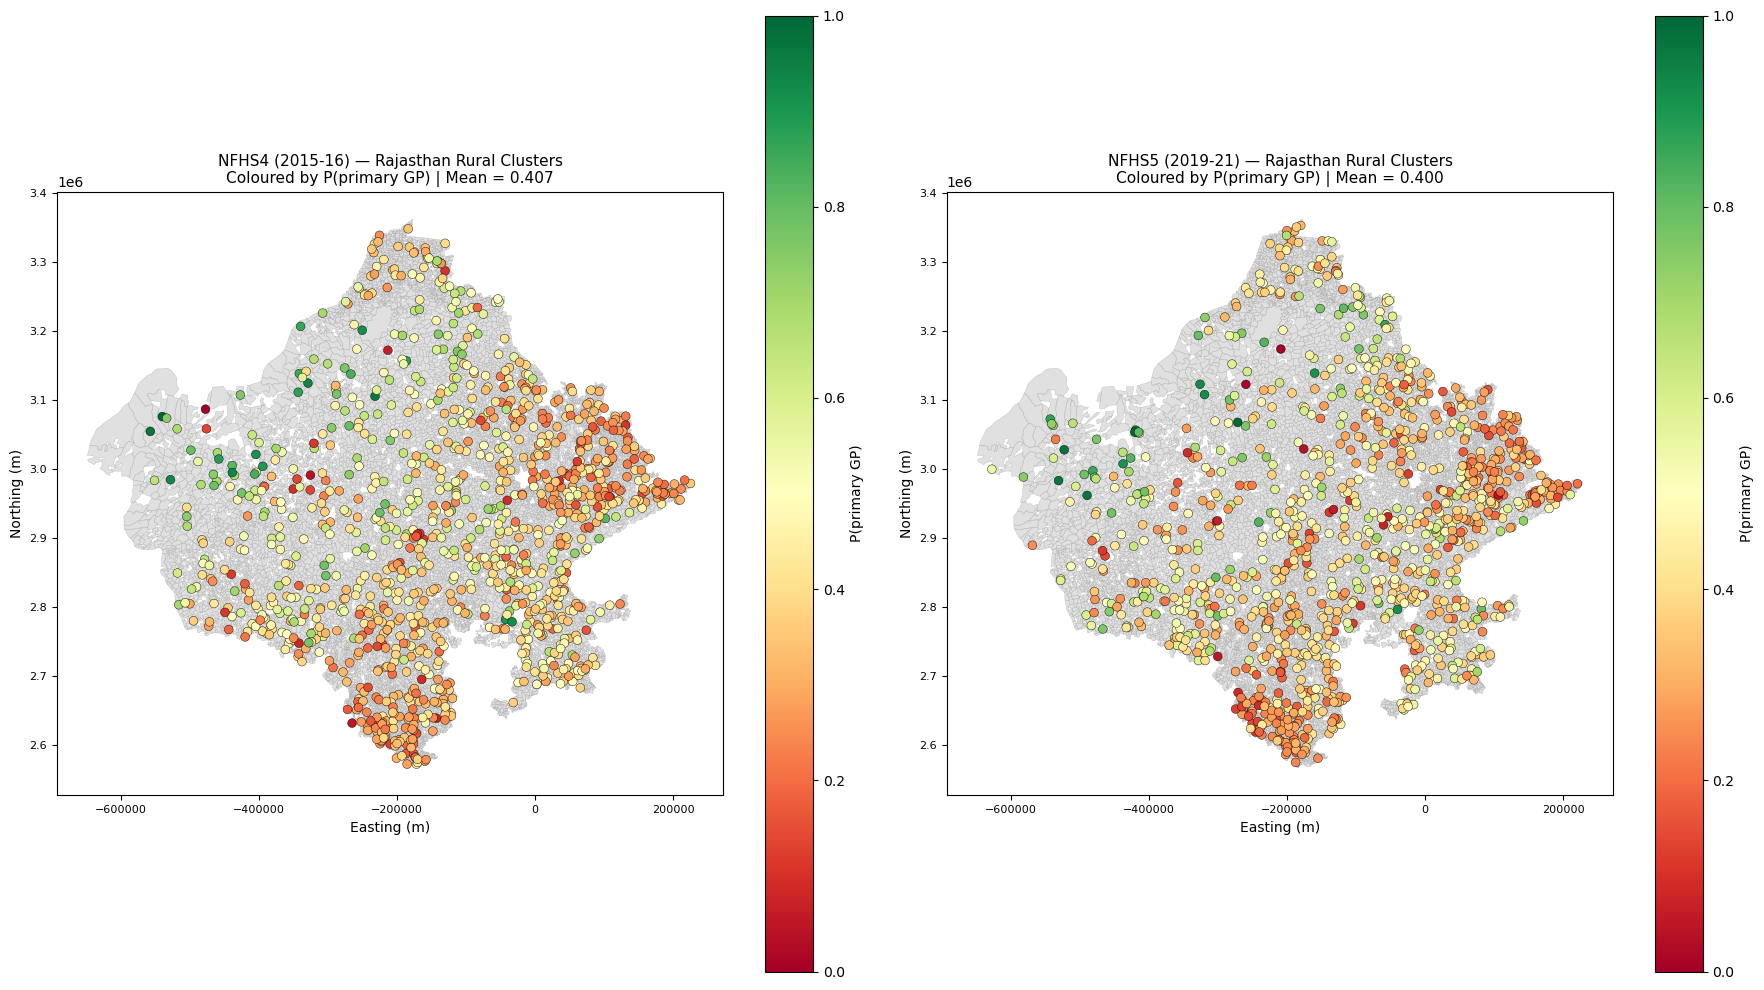

In [40]:
# =============================================================================
# CELL 17 — Visualisation: Full Rajasthan Map
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

for ax, mc_df, clusters_gdf, round_name in [
    (axes[0], mc_nfhs4_rj, nfhs4_rj, "NFHS4 (2015-16)"),
    (axes[1], mc_nfhs5_rj, nfhs5_rj, "NFHS5 (2019-21)")
]:
    # Plot GP boundaries
    gp_polygons_rj.plot(
        ax=ax,
        color="lightgrey",
        edgecolor="darkgrey",
        linewidth=0.3,
        alpha=0.7
    )

    # Merge probabilities onto cluster locations
    clusters_plot = clusters_gdf.merge(
        mc_df[["DHSCLUST", "primary_gp_prob", "n_gps_hit"]],
        on="DHSCLUST", how="left"
    )

    scatter = ax.scatter(
        clusters_plot.geometry.x,
        clusters_plot.geometry.y,
        c=clusters_plot["primary_gp_prob"],
        cmap="RdYlGn",
        vmin=0, vmax=1,
        s=40,
        edgecolors="black",
        linewidth=0.3,
        zorder=5
    )

    plt.colorbar(scatter, ax=ax, label="P(primary GP)")
    ax.set_title(
        f"{round_name} — Rajasthan Rural Clusters\n"
        f"Coloured by P(primary GP) | "
        f"Mean = {mc_df['primary_gp_prob'].mean():.3f}",
        fontsize=11
    )
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "monte carlo simulation rajasthan" / "rajasthan_monte_carlo_map.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Map saved.")

In [39]:
# =============================================================================
# CELL 18 — Save Full Rajasthan Results
# =============================================================================

OUTPUT_MC = OUTPUT_DIR / "monte carlo simulation ganganagar"
OUTPUT_MC.mkdir(parents=True, exist_ok=True)

mc_nfhs4_rj.to_csv(OUTPUT_MC / "rajasthan_mc_nfhs4.csv", index=False)
mc_nfhs5_rj.to_csv(OUTPUT_MC / "rajasthan_mc_nfhs5.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_MC / 'rajasthan_mc_nfhs4.csv'}")
print(f"  {OUTPUT_MC / 'rajasthan_mc_nfhs5.csv'}")
print(f"\nRows: NFHS4={len(mc_nfhs4_rj)}, NFHS5={len(mc_nfhs5_rj)}")
print("\nNext steps:")
print("  1. Share results with coauthors at upcoming meeting")
print("  2. Once GP reservation data is cleanly merged, extend to compute")
print("     P(correct treatment status) for each cluster")
print("  3. Scale pipeline to Uttar Pradesh")

Saved:
  ../outputs/monte carlo simulation ganganagar/monte carlo simulation ganganagar/rajasthan_mc_nfhs4.csv
  ../outputs/monte carlo simulation ganganagar/monte carlo simulation ganganagar/rajasthan_mc_nfhs5.csv

Rows: NFHS4=1190, NFHS5=1163

Next steps:
  1. Share results with coauthors at upcoming meeting
  2. Once GP reservation data is cleanly merged, extend to compute
     P(correct treatment status) for each cluster
  3. Scale pipeline to Uttar Pradesh
